# Import Libraries

In [10]:
!uv pip install pgmpy

Using Python 3.13.15 environment at: /usr
Resolved 37 packages in 294ms
Prepared 2 packages in 81ms
Installed 2 packages in 12ms
 + pgmpy==1.1.2
 + scikit-base==1.1.1


In [11]:
%time
import networkx as nx
import matplotlib.pyplot as plt

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 3.81 µs


# Create graph


In [12]:
H = nx.DiGraph()

nodes = ["Rain", "Accident", "Traffic", "Heavy_Vehicle"]

H.add_nodes_from(nodes)

edges = [("Rain", "Traffic"),("Accident", "Traffic"),("Heavy_Vehicle", "Traffic")]

H.add_edges_from(edges)


# Draw Bayesian Network

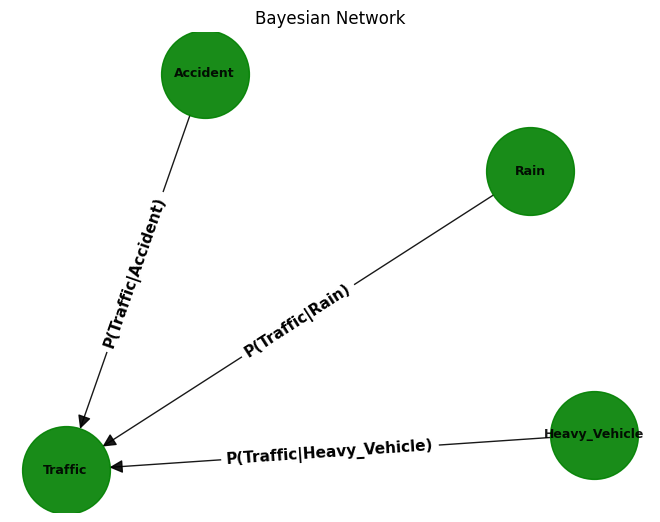

In [13]:
pos = nx.spring_layout(H, seed=70)

nx.draw(H, pos, with_labels=True, node_size=4000, node_color="Green", alpha=0.9, font_size=9, arrowsize=20, font_weight="bold", font_color="k")

labels = {
    ("Rain", "Traffic"): "P(Traffic|Rain)",
    ("Accident", "Traffic"): "P(Traffic|Accident)",
    ("Heavy_Vehicle", "Traffic"): "P(Traffic|Heavy_Vehicle)"
}

nx.draw_networkx_edge_labels(H, pos, edge_labels=labels, font_size=11, font_weight="bold", font_color="k")

plt.title("Bayesian Network")
plt.show()



# Create Bayesian Network


In [15]:
Network = DiscreteBayesianNetwork(edges)

# CPD of Rain


In [16]:
cpd_Rain = TabularCPD(variable="Rain", variable_card=2, values=[[0.2],[0.8]])

# CPD of Accident


In [17]:
cpd_Accident = TabularCPD(variable="Accident", variable_card=2, values=[[0.95],[0.05]])

# CPD of Heavy Vehicle


In [18]:
cpd_Heavy_Vehicle = TabularCPD(variable="Heavy_Vehicle", variable_card=2, values=[[0.25],[0.75]])


# CPD of Traffic


In [19]:

cpd_Traffic = TabularCPD(variable="Traffic", variable_card=2, values=[[0, 0.25, 0.95, 0.9625, 0.2, 0.4, 0.06, 0.07],
                                                                      [1, 0.75, 0.05, 0.0375, 0.8, 0.6, 0.94, 0.93]],
                         evidence=["Rain", "Accident", "Heavy_Vehicle"],
                         evidence_card=[2, 2, 2])

# Add CPDs


In [20]:
Network.add_cpds(cpd_Rain, cpd_Accident, cpd_Heavy_Vehicle, cpd_Traffic)


# Print CPDs
print("The CPD of Rain is :\n", cpd_Rain)
print("The CPD of Accident is :\n", cpd_Accident)
print("The CPD of Heavy_Vehicle is :\n", cpd_Heavy_Vehicle)
print("The CPD of Traffic is :\n", cpd_Traffic)

The CPD of Rain is :
 +---------+-----+
| Rain(0) | 0.2 |
+---------+-----+
| Rain(1) | 0.8 |
+---------+-----+
The CPD of Accident is :
 +-------------+------+
| Accident(0) | 0.95 |
+-------------+------+
| Accident(1) | 0.05 |
+-------------+------+
The CPD of Heavy_Vehicle is :
 +------------------+------+
| Heavy_Vehicle(0) | 0.25 |
+------------------+------+
| Heavy_Vehicle(1) | 0.75 |
+------------------+------+
The CPD of Traffic is :
 +---------------+------------------+-----+------------------+
| Rain          | Rain(0)          | ... | Rain(1)          |
+---------------+------------------+-----+------------------+
| Accident      | Accident(0)      | ... | Accident(1)      |
+---------------+------------------+-----+------------------+
| Heavy_Vehicle | Heavy_Vehicle(0) | ... | Heavy_Vehicle(1) |
+---------------+------------------+-----+------------------+
| Traffic(0)    | 0.0              | ... | 0.07             |
+---------------+------------------+-----+-------------

# Extract probabilities


In [21]:
P_Rain = cpd_Rain.values[1]

P_Accident = cpd_Accident.values[1]

P_Heavy_Vehicle = cpd_Heavy_Vehicle.values[1]


print("\nExample Extracted Probabilities:")
print("P(Rain) = ", P_Rain)
print("P(Accident) = ", P_Accident)
print("P(Heavy_Vehicle) = ", P_Heavy_Vehicle)


Example Extracted Probabilities:
P(Rain) =  0.8
P(Accident) =  0.05
P(Heavy_Vehicle) =  0.75


# Final probability calculation


In [25]:
P_Rain = cpd_Rain.values[1]

P_Accident = cpd_Accident.values[0]

P_Heavy_Vehicle = cpd_Heavy_Vehicle.values[1]

P_Traffic_given_Rain_not_Accident_Heavy_Vehicle = (
    cpd_Traffic.values[1, 1, 0, 1]
)

P_Traffic = (
    P_Rain
    * P_Accident
    * P_Heavy_Vehicle
    * P_Traffic_given_Rain_not_Accident_Heavy_Vehicle
)

print(
    "P(Rain=T, Accident=F, Heavy_Vehicle=T, Traffic=T) =",
    P_Traffic
)

P(Rain=T, Accident=F, Heavy_Vehicle=T, Traffic=T) = 0.342
